In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')
import keras

In [43]:
import shap

In [44]:
red = pd.read_csv('redwinequality.csv',sep=';')
white = pd.read_csv('whitewinequality.csv',sep=';')




In [45]:
red

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [46]:
white

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [47]:
red['type']=1 #classifying
white['type']=0
wines = pd.concat([red,white],ignore_index=True) #as one dataframe
wines.dropna(inplace=True) #permanently removing na
wines.shape

(6497, 13)

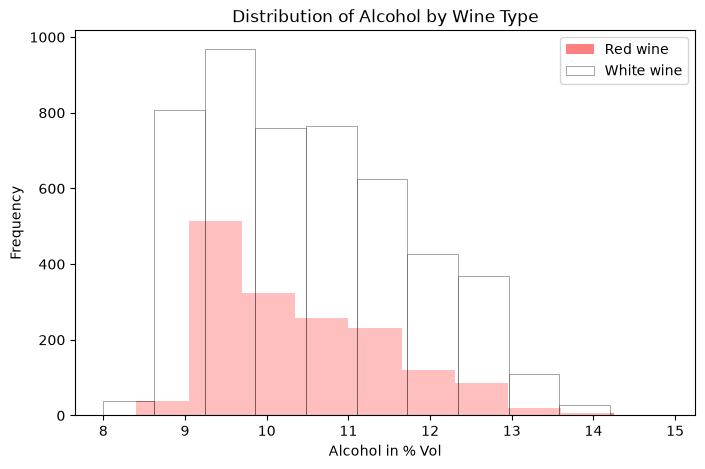

In [48]:
plt.figure(figsize=(8, 5))
plt.hist(wines[wines['type'] == 1].alcohol, bins=10, facecolor='red', alpha=0.5, label='Red wine')
plt.hist(wines[wines['type'] == 0].alcohol, bins=10, facecolor='white', edgecolor='black', lw=0.5, alpha=0.5, label='White wine')
plt.xlabel('Alcohol in % Vol')
plt.ylabel('Frequency')
plt.title('Distribution of Alcohol by Wine Type')
plt.legend()
plt.show()

In [49]:
from sklearn.model_selection import train_test_split
X = wines.iloc[:, :-1] # except the last type
y = wines['type']
X_train , X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.20, random_state=42)
feature_names = X.columns.tolist()


In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [51]:
logreg = LogisticRegression(max_iter=1000, random_state=45)
logreg.fit(X_train_scaled, y_train)
 
logreg_pred = logreg.predict(X_test_scaled)
print("=== Logistic Regression Baseline ===")
print(f"Accuracy: {accuracy_score(y_test, logreg_pred):.4f}")
print(classification_report(y_test, logreg_pred, target_names=["White", "Red"]))


=== Logistic Regression Baseline ===
Accuracy: 0.9892
              precision    recall  f1-score   support

       White       0.99      0.99      0.99       959
         Red       0.98      0.98      0.98       341

    accuracy                           0.99      1300
   macro avg       0.99      0.99      0.99      1300
weighted avg       0.99      0.99      0.99      1300



In [52]:
from keras.models import Sequential
from keras.layers import Dense,Input
model = Sequential()
model.add(keras.Input(shape=(12,)))
model.add(Dense(12,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid')) #binary classifiation problem to choose the type of wine it is
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),loss=keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])


In [58]:
model.fit(X_train_scaled, y_train, epochs=20, batch_size=16, verbose=1,
          validation_split=0.1)

y_pred = model.predict(X_test_scaled)
y_pred_labels = (y_pred >= 0.5).astype(int)

print(f"Accuracy: {accuracy_score(y_test, y_pred_labels):.4f}")
print(classification_report(y_test, y_pred_labels, target_names=["White", "Red"]))


Epoch 1/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.9985 - loss: 0.0070 - val_accuracy: 0.9981 - val_loss: 0.0244
Epoch 2/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy: 0.9987 - loss: 0.0069 - val_accuracy: 0.9981 - val_loss: 0.0243
Epoch 3/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step - accuracy: 0.9987 - loss: 0.0067 - val_accuracy: 0.9981 - val_loss: 0.0254
Epoch 4/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - accuracy: 0.9987 - loss: 0.0066 - val_accuracy: 0.9981 - val_loss: 0.0247
Epoch 5/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step - accuracy: 0.9987 - loss: 0.0065 - val_accuracy: 0.9981 - val_loss: 0.0249
Epoch 6/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step - accuracy: 0.9987 - loss: 0.0062 - val_accuracy: 0.9981 - val_loss: 0.0250
Epoch 7/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - accuracy: 0.9987 - loss: 0.0064 - val_accuracy: 0.9981 - val_loss: 0.0255
Epoch 8/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step - accuracy: 0.9987 - loss: 0.0061 - 

In [59]:
background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)]
explainer = shap.KernelExplainer(model.predict, background)
 
sample = X_test_scaled[:200]  # subsample of test set for speed
shap_values = explainer.shap_values(sample)
 
sv = np.array(shap_values)
if sv.ndim == 3:
    sv = sv.squeeze(-1)
 
mean_abs_shap = np.abs(sv).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
 
print("\n=== Top features the Neural Net relies on (SHAP) ===")
print(importance_df.head(8).to_string(index=False))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


  0%|                                                  | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 2s 378us/step


  0%|▏                                         | 1/200 [00:03<11:44,  3.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 2s 367us/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 3s 433us/step


100%|███████████████████████████████████████▊| 199/200 [12:58<00:03,  3.94s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
6475/6475 ━━━━━━━━━━━━━━━━━━━━ 3s 409us/step


100%|████████████████████████████████████████| 200/200 [13:01<00:00,  3.91s/it]


=== Top features the Neural Net relies on (SHAP) ===
             feature  mean_abs_shap
total sulfur dioxide       0.180702
             density       0.151388
      residual sugar       0.061463
           chlorides       0.046612
             alcohol       0.037067
    volatile acidity       0.031418
 free sulfur dioxide       0.029082
           sulphates       0.016800


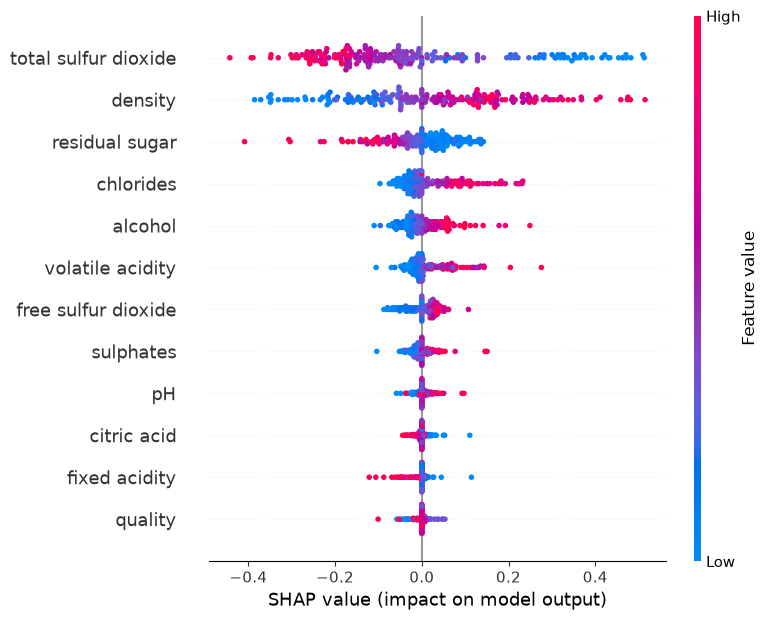

In [63]:
shap.summary_plot(sv, sample, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()
plt.close()


 
